# Stage 8: Causal stress tests

Test practical overlap failure and hidden confounding in six prespecified
scenarios: baseline, moderate/severe overlap, moderate/severe hidden confounding,
and combined severe stress. The default report uses **five paired seeds** and
**20,000 customers per scenario/seed**, refitting S/T/DR each time (30 fits per
learner). Train/calibration/evaluation remain 70/15/15, with $80 retention value,
$10 cost, and a strict 20% capacity.

Poor-overlap interventions change assignment while preserving response surfaces.
Hidden confounding changes both assignment and retention through a latent binary
common cause. Causal CATE truth integrates that cause out, conditioning only on
the observed features. All latent and simulator truth columns are excluded from
model fitting, prediction, and policy calibration.

This notebook renders published experiment tables. Run
`.venv\Scripts\python.exe scripts/run_stage8.py` for the complete computation.
See [methodology and limitations](../docs/stage_8_causal_stress.md).

In [1]:
from pathlib import Path
import os
import sys

# Start Jupyter from the repository/notebooks directory, or explicitly set
# CAUSAL_INFERENCE_ROOT when the kernel starts elsewhere.
configured_root = os.environ.get("CAUSAL_INFERENCE_ROOT")
current_directory = Path.cwd().resolve()
candidates = (
    [Path(configured_root).expanduser().resolve()]
    if configured_root
    else [current_directory, *current_directory.parents]
)
PROJECT_ROOT = next(
    (
        candidate for candidate in candidates
        if all(
            (candidate / "src" / filename).is_file()
            for filename in ("causal_learners.py", "policies.py", "simulation.py")
        )
        and (candidate / "notebooks" / "06_causal_stress_tests.ipynb").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the Causal_Inference repository. Start Jupyter from "
        "the project or notebooks directory, or set CAUSAL_INFERENCE_ROOT "
        "to the repository path before running this notebook."
    )

SRC_DIRECTORY = PROJECT_ROOT / "src"
if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from causal_stress import STRESS_SCENARIOS, paired_baseline_deltas

sns.set_theme(style="whitegrid", context="notebook")
TABLES = PROJECT_ROOT / "reports" / "tables"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
manifest = json.loads((TABLES / "stage8_manifest.json").read_text(encoding="utf-8"))
effects = pd.read_csv(TABLES / "stage8_effects_by_seed.csv")
policies = pd.read_csv(TABLES / "stage8_policies_by_seed.csv")
diagnostics = pd.read_csv(TABLES / "stage8_diagnostics_by_seed.csv")
clipping = pd.read_csv(TABLES / "stage8_clipping_by_seed.csv")
histograms = pd.read_csv(TABLES / "stage8_overlap_histograms.csv")
effect_summary = pd.read_csv(TABLES / "stage8_effect_summary.csv")
policy_summary = pd.read_csv(TABLES / "stage8_policy_summary.csv")
SCENARIOS = [s[0] for s in manifest["config"]["stress_scenarios"]]
SEEDS = manifest["config"]["seeds"]
MODELS = ["S-learner", "T-learner", "DR-learner"]

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / name, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Seeds:", SEEDS)
print("Scenarios:", SCENARIOS)
print("Configuration fingerprint:", manifest["experiment_fingerprint"])


Seeds: [42, 43, 44, 45, 46]
Scenarios: ['Baseline', 'Moderate overlap', 'Severe overlap', 'Moderate hidden', 'Severe hidden', 'Combined severe']
Configuration fingerprint: 946e1e4537cf3540a67a282c1a6717916fba628d10091f8dc41db1697dc0840c


## 1. Verify overlap stress and propensity estimation

The true propensity below is `P(T=1 | X)`, marginal over latent U. Plot its
held-out distribution by observed treatment. Moderate/severe overlap sharpens
assignment by factors 2.5/5 with a 0.001–0.999 floor/ceiling. This creates weak
practical overlap while preserving strictly positive assignment probabilities.
Overlap may remain apparently adequate after marginalizing U even when hidden
confounding is strong: good observed overlap does not establish exchangeability.

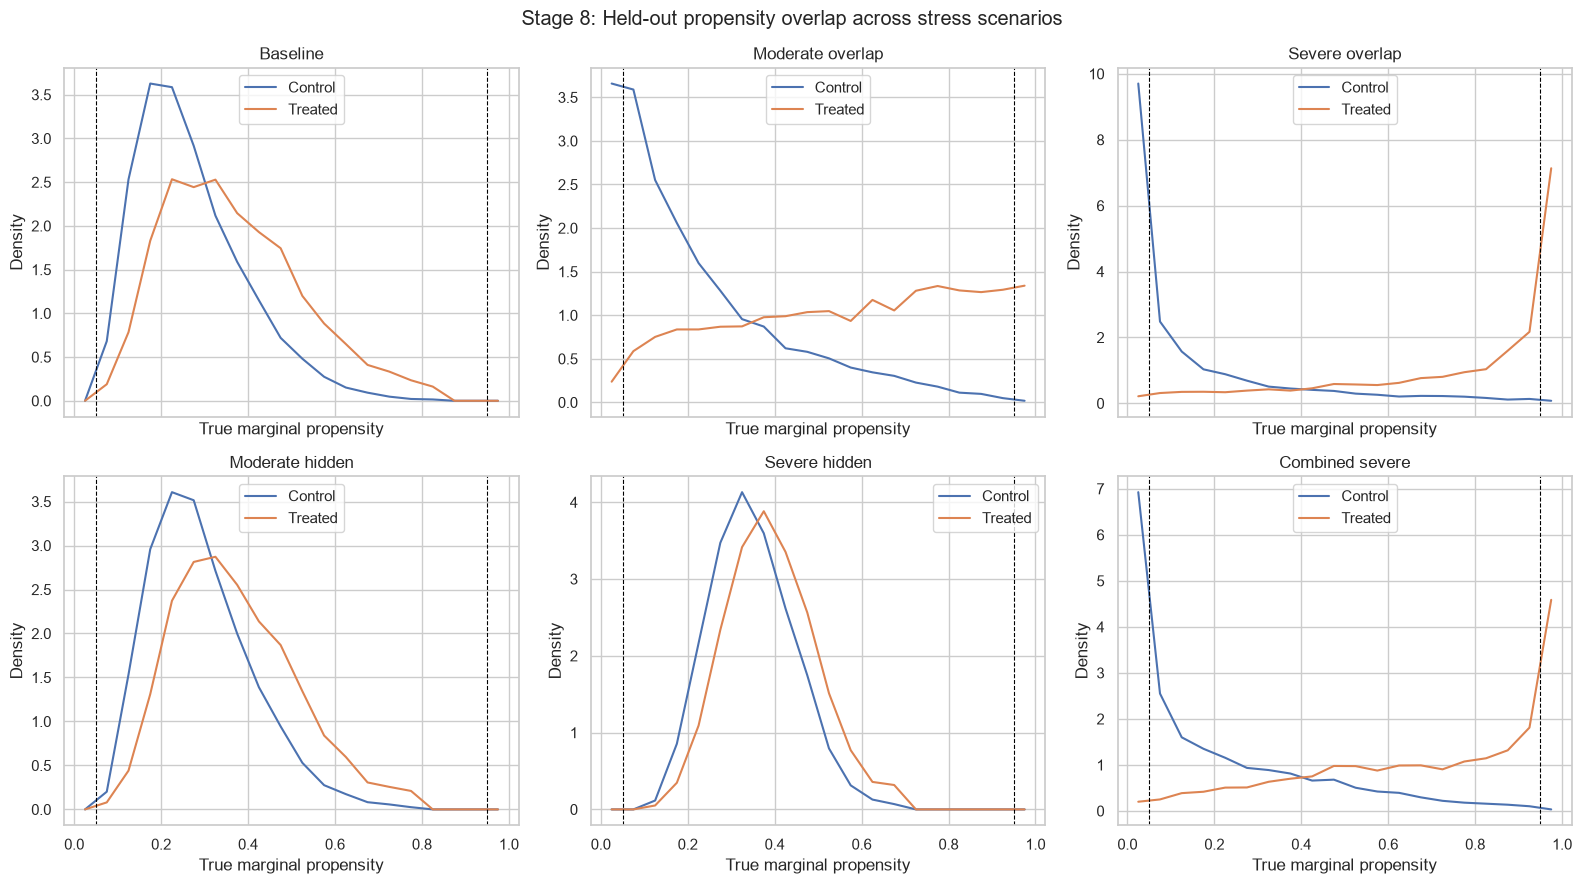

,scenario,metric,replicates,mean,std,mcse,median,minimum,maximum,q025,q975
0,Baseline,true_ate,5,1.547294e-01,1.783559e-03,7.976320e-04,0.153720,1.531881e-01,1.567924e-01,1.532092e-01,1.567678e-01
1,Baseline,estimated_aipw_ate,5,1.551869e-01,2.103312e-02,9.406296e-03,0.148346,1.327737e-01,1.841971e-01,1.336510e-01,1.826845e-01
2,Baseline,reference_aipw_ate,5,1.600546e-01,2.091560e-02,9.353739e-03,0.154710,1.369956e-01,1.876746e-01,1.378806e-01,1.864119e-01
3,Baseline,analytic_identification_gap,5,5.551115e-18,1.241267e-17,5.551115e-18,0.000000,0.000000e+00,2.775558e-17,0.000000e+00,2.498002e-17
4,Baseline,true_weak_overlap_fraction,5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,Baseline,estimated_weak_overlap_fraction,5,3.333333e-04,3.333333e-04,1.490712e-04,0.000333,0.000000e+00,6.666667e-04,0.000000e+00,6.666667e-04
6,Baseline,clipped_weight_ess,5,2.070947e+03,6.351734e+01,2.840582e+01,2089.868397,1.964471e+03,2.128381e+03,1.974767e+03,2.126002e+03
7,Baseline,trimmed_true_ate,5,1.547773e-01,1.765275e-03,7.894550e-04,0.153811,1.531881e-01,1.567924e-01,1.532191e-01,1.567728e-01
8,Baseline,trimmed_estimated_aipw_ate,5,1.552624e-01,2.097644e-02,9.380950e-03,0.148489,1.328419e-01,1.841971e-01,1.337290e-01,1.826845e-01
9,Combined severe,true_ate,5,1.151065e-01,1.395336e-03,6.240132e-04,0.115462,1.133322e-01,1.166031e-01,1.133991e-01,1.165561e-01


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for axis, scenario in zip(axes.flat, SCENARIOS):
    rows = histograms[(histograms.scenario == scenario) & (histograms.kind == "True marginal")]
    for arm, label in [(0, "Control"), (1, "Treated")]:
        counts = rows[rows.treatment == arm].groupby(["bin_left", "bin_right"])["count"].sum().reset_index()
        middle = (counts.bin_left+counts.bin_right)/2
        density = counts["count"]/(counts["count"].sum()*(counts.bin_right-counts.bin_left))
        axis.plot(middle, density, label=label)
    axis.axvline(.05, color="black", linestyle="--", linewidth=.8)
    axis.axvline(.95, color="black", linestyle="--", linewidth=.8)
    axis.set(title=scenario, xlabel="True marginal propensity", ylabel="Density")
    axis.legend()
fig.suptitle("Stage 8: Held-out propensity overlap across stress scenarios")
save(fig, "stage8_propensity_overlap.png")
display(pd.read_csv(TABLES / "stage8_diagnostic_summary.csv"))

## 2. CATE estimation under stress

Each point is one independent seed cohort. Models are refitted under each
scenario. Poor overlap holds true effects fixed, while hidden confounding also
changes causal response probabilities and hence the target effects. Therefore
between-scenario PEHE changes are descriptive and not a pure decomposition of
identification bias. There is no assertion that performance must worsen
monotonically or that DR must always outperform S/T.

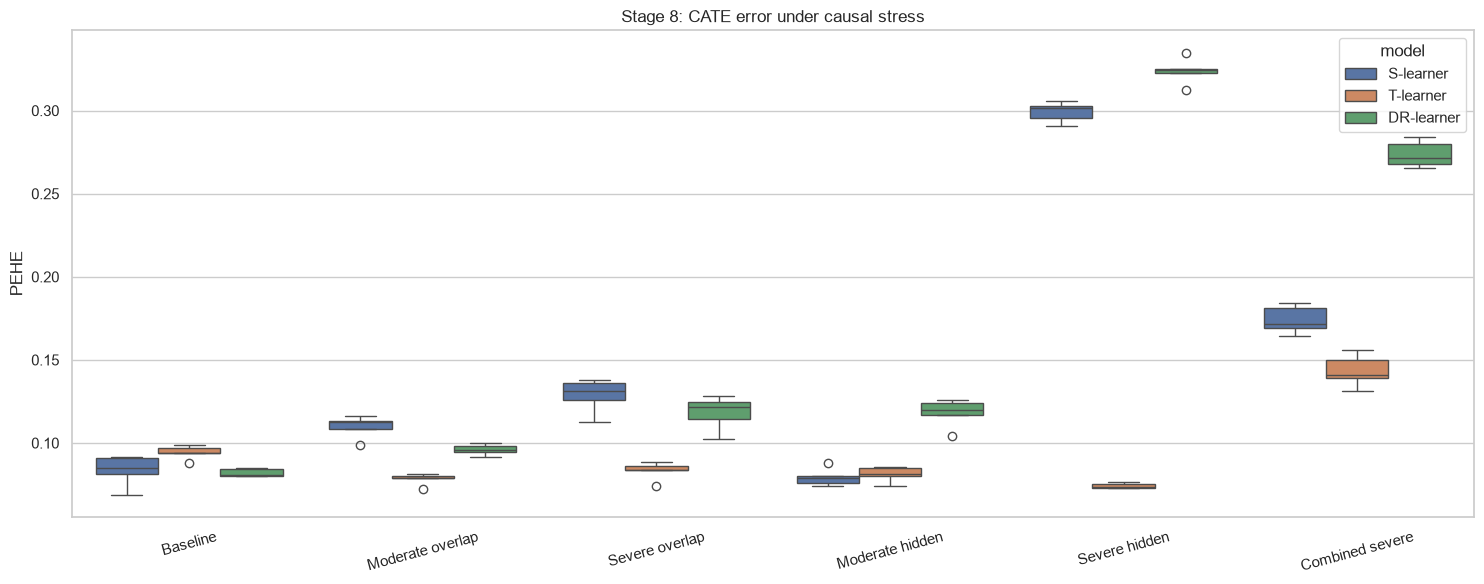

,scenario,model,metric,replicates,mean,std,mcse,median,minimum,maximum,q025,q975
0,Baseline,DR-learner,ate_error,5,0.007554,0.004216,0.001886,0.006613,0.003400,0.014361,0.003569,0.013755
1,Baseline,DR-learner,pehe,5,0.082122,0.002423,0.001083,0.080986,0.079987,0.085077,0.080006,0.085007
4,Baseline,S-learner,ate_error,5,0.056458,0.010888,0.004869,0.056926,0.038816,0.067069,0.040530,0.066714
5,Baseline,S-learner,pehe,5,0.083552,0.009309,0.004163,0.084731,0.068815,0.091614,0.070074,0.091572
8,Baseline,T-learner,ate_error,5,0.062179,0.006077,0.002718,0.061434,0.054723,0.071080,0.055188,0.070401
9,Baseline,T-learner,pehe,5,0.094436,0.004127,0.001846,0.094071,0.088129,0.098894,0.088699,0.098730
12,Combined severe,DR-learner,ate_error,5,0.243006,0.007323,0.003275,0.243094,0.235841,0.253745,0.235921,0.252942
13,Combined severe,DR-learner,pehe,5,0.273763,0.008026,0.003589,0.271411,0.265510,0.284197,0.265731,0.283775
16,Combined severe,S-learner,ate_error,5,0.149625,0.007910,0.003538,0.146139,0.141566,0.160940,0.141908,0.160295
17,Combined severe,S-learner,pehe,5,0.174188,0.008342,0.003731,0.171854,0.164303,0.184149,0.164798,0.183872


In [4]:
fig, axis = plt.subplots(figsize=(15, 6))
sns.boxplot(data=effects, x="scenario", y="pehe", hue="model", order=SCENARIOS,
            hue_order=MODELS, ax=axis)
axis.set(title="Stage 8: CATE error under causal stress", xlabel="", ylabel="PEHE")
axis.tick_params(axis="x", labelrotation=15)
save(fig, "stage8_effect_errors.png")
display(effect_summary[effect_summary.metric.isin(["pehe", "ate_error"])])

## 3. Identification failure despite perfect observational nuisances

`E[Y | X,T=1] - E[Y | X,T=0]` is an observational contrast. Its difference from
`E[Y(1)-Y(0) | X]` is exactly calculable in this simulator. With hidden U, even
perfect propensity and observed-outcome nuisance functions recover that
confounded contrast rather than causal CATE. The analytic gap is a DGP
diagnostic—not a quantity normally observable with real data.

Reference AIPW uses these known observational nuisance functions only as an
evaluation diagnostic (clipping 0.001). It never trains models or chooses
policies. It can still show large finite-sample error under poor overlap.
The analytic comparison avoids confusing that sampling noise with identification
failure. Cross-fitting, clipping, and double robustness cannot remove hidden
common causes.

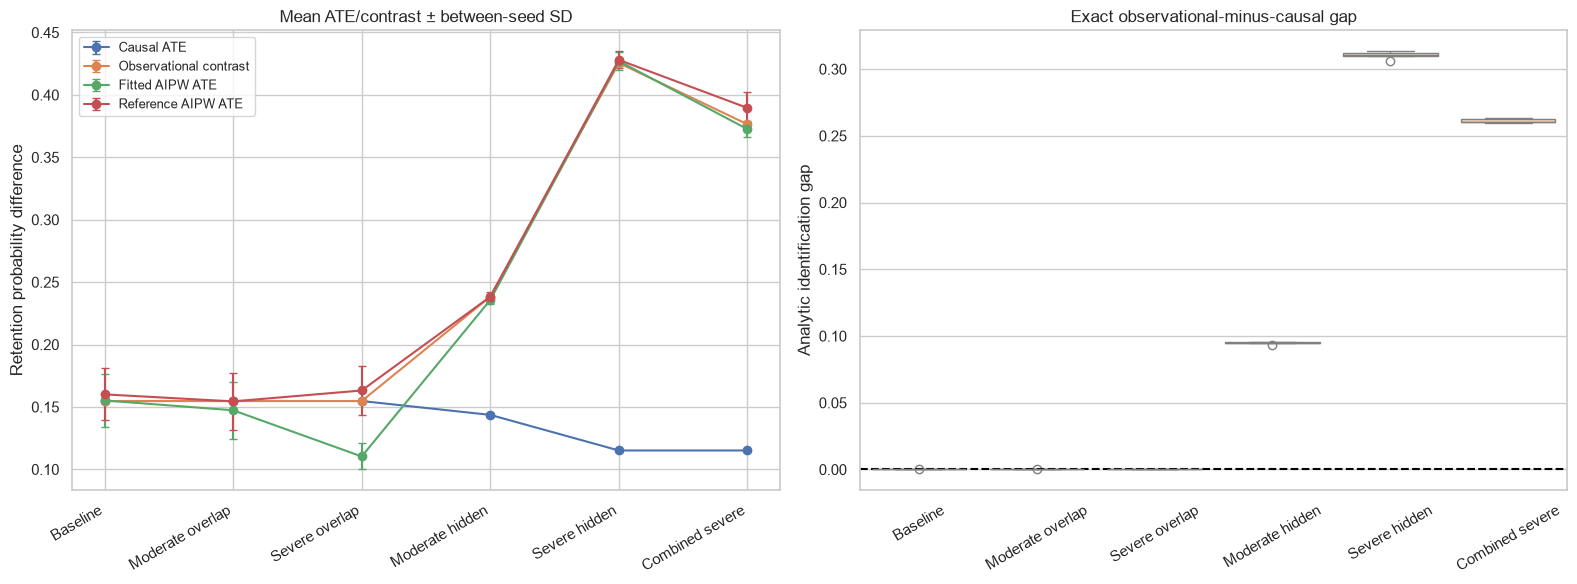

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
positions = np.arange(len(SCENARIOS))
for metric, label in [("true_ate", "Causal ATE"), ("analytic_association_ate", "Observational contrast"),
                      ("estimated_aipw_ate", "Fitted AIPW ATE"), ("reference_aipw_ate", "Reference AIPW ATE")]:
    group = diagnostics.groupby("scenario")[metric].agg(["mean", "std"]).reindex(SCENARIOS)
    axes[0].errorbar(positions, group["mean"], yerr=group["std"], marker="o", capsize=3, label=label)
axes[0].set_xticks(positions, SCENARIOS, rotation=30, ha="right")
axes[0].set(title="Mean ATE/contrast ± between-seed SD", ylabel="Retention probability difference")
axes[0].legend(fontsize=9)
sns.boxplot(data=diagnostics, x="scenario", y="analytic_identification_gap", order=SCENARIOS, ax=axes[1], color="#FED7AA")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].tick_params(axis="x", labelrotation=30)
axes[1].set(title="Exact observational-minus-causal gap", xlabel="", ylabel="Analytic identification gap")
save(fig, "stage8_identification_failure.png")

## 4. Targeting performance and observational profit error

True expected profits use response surfaces marginal over U. The oracle is an
upper bound for policies using observed X. It does not select customers using U.
Report percent of oracle profit as well as raw profit because hidden confounding
changes the causal response scale. An apparent favorable observational profit
estimate does not establish true causal campaign value.

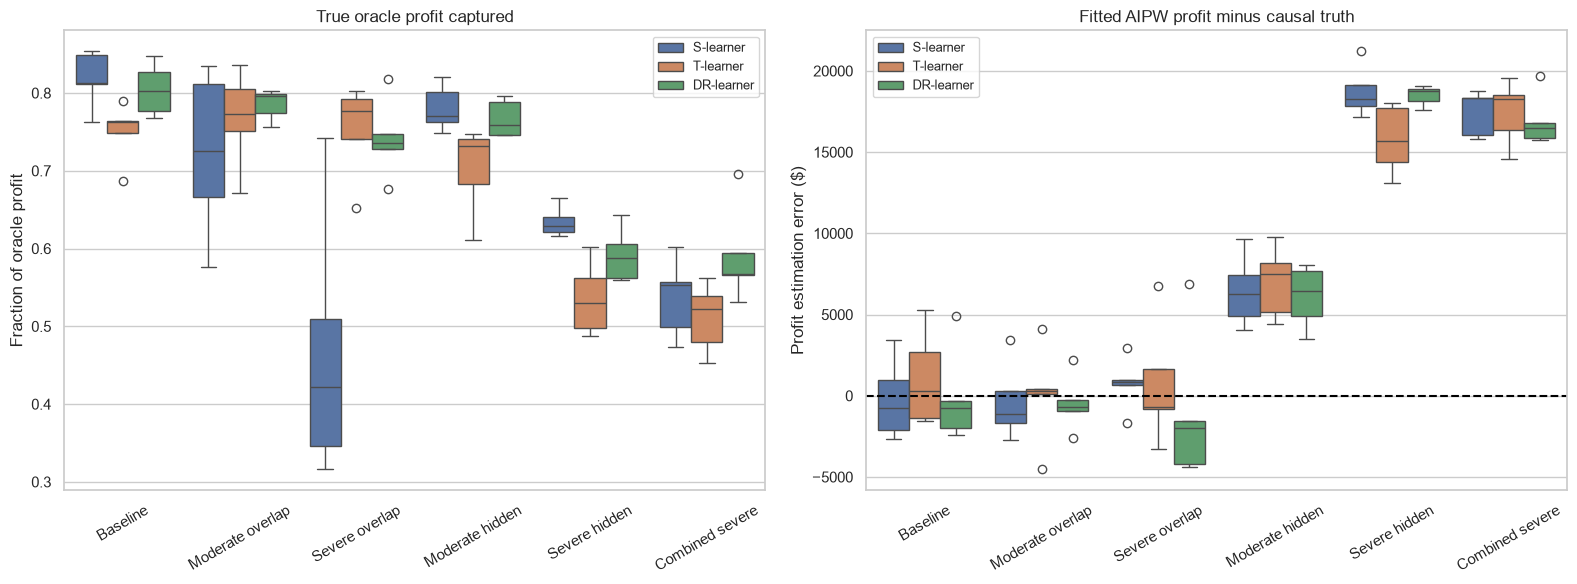

,scenario,policy,metric,replicates,mean,std,mcse,median,minimum,maximum,q025,q975
0,Baseline,DR-learner,incremental_profit,5,7018.516912,415.940173,186.014100,6994.430222,6591.998497,7518.560596,6596.243676,7502.019032
1,Baseline,DR-learner,oracle_profit_captured,5,0.804367,0.033211,0.014853,0.802549,0.767726,0.847195,0.768699,0.845166
3,Baseline,DR-learner,estimated_profit_error,5,-117.593968,2927.050572,1309.016811,-748.627605,-2422.189155,4882.264775,-2379.558735,4363.685008
5,Baseline,Oracle,incremental_profit,5,8720.435022,163.009440,72.900038,8715.271991,8533.482042,8892.365443,8538.773702,8890.594598
6,Baseline,Oracle,oracle_profit_captured,5,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
171,Severe overlap,T-learner,oracle_profit_captured,5,0.752966,0.061267,0.027399,0.777452,0.651744,0.802304,0.660629,0.801347
173,Severe overlap,T-learner,estimated_profit_error,5,733.586174,3803.383030,1700.924600,-699.398815,-3256.606153,6780.098325,-3013.918089,6269.444795
175,Severe overlap,Treat nobody,incremental_profit,5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
176,Severe overlap,Treat nobody,oracle_profit_captured,5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
learned = policies[policies.policy.isin(MODELS)]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=learned, x="scenario", y="oracle_profit_captured", hue="policy", order=SCENARIOS, hue_order=MODELS, ax=axes[0])
sns.boxplot(data=learned, x="scenario", y="estimated_profit_error", hue="policy", order=SCENARIOS, hue_order=MODELS, ax=axes[1])
axes[0].set(title="True oracle profit captured", ylabel="Fraction of oracle profit", xlabel="")
axes[1].set(title="Fitted AIPW profit minus causal truth", ylabel="Profit estimation error ($)", xlabel="")
axes[1].axhline(0, color="black", linestyle="--")
for axis in axes:
    axis.tick_params(axis="x", labelrotation=30)
    axis.legend(fontsize=9)
save(fig, "stage8_policy_stress.png")
display(policy_summary[policy_summary.metric.isin(["incremental_profit", "oracle_profit_captured", "estimated_profit_error"])])

## 5. Stabilization sensitivity and trimming's changed target

Vary evaluation-only clipping to 0.01/0.05/0.10 while holding models and policies
fixed. It changes weights, not identification. These are not retrained CATE
models. Separately restrict evaluation to estimated propensities in [0.05,0.95]
and report that subset's ATE alongside the original population ATE. Trimming
changes the target population; its apparent improvement must not be interpreted
as recovery of the original full-population effect or a cure for hidden U.

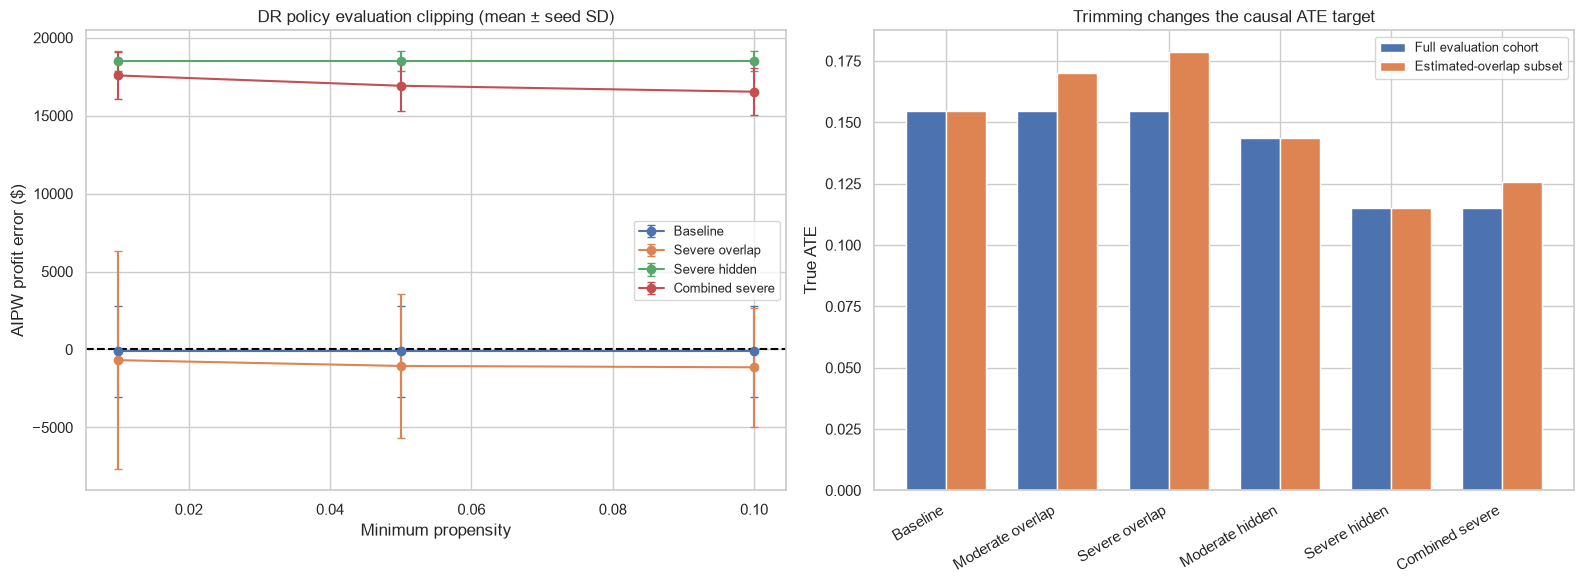

,seed,scenario,evaluation_customers,trimmed_customers,true_ate,trimmed_true_ate,trimmed_estimated_aipw_ate
0,42,Baseline,3000,2998,0.153720,0.153811,0.141713
1,42,Moderate overlap,3000,2583,0.153720,0.170711,0.148140
2,42,Severe overlap,3000,1883,0.153720,0.179978,0.151999
3,42,Moderate hidden,3000,2998,0.143073,0.143164,0.237969
4,42,Severe hidden,3000,3000,0.115462,0.115462,0.428900
5,42,Combined severe,3000,2236,0.115462,0.126179,0.427961
6,43,Baseline,3000,3000,0.156792,0.156792,0.184197
7,43,Moderate overlap,3000,2643,0.156792,0.170535,0.195081
8,43,Severe overlap,3000,1927,0.156792,0.177444,0.180804
9,43,Moderate hidden,3000,3000,0.145387,0.145387,0.239632


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for scenario in ["Baseline", "Severe overlap", "Severe hidden", "Combined severe"]:
    frame = clipping[(clipping.scenario == scenario) & (clipping.policy == "DR-learner")]
    group = frame.groupby("propensity_clip").estimated_profit_error.agg(["mean", "std"])
    axes[0].errorbar(group.index, group["mean"], yerr=group["std"], capsize=3, marker="o", label=scenario)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(title="DR policy evaluation clipping (mean ± seed SD)", xlabel="Minimum propensity", ylabel="AIPW profit error ($)")
axes[0].legend(fontsize=9)
full = diagnostics.groupby("scenario").true_ate.mean().reindex(SCENARIOS)
trimmed = diagnostics.groupby("scenario").trimmed_true_ate.mean().reindex(SCENARIOS)
axes[1].bar(positions-.18, full, .36, label="Full evaluation cohort")
axes[1].bar(positions+.18, trimmed, .36, label="Estimated-overlap subset")
axes[1].set_xticks(positions, SCENARIOS, rotation=30, ha="right")
axes[1].set(title="Trimming changes the causal ATE target", ylabel="True ATE")
axes[1].legend(fontsize=9)
save(fig, "stage8_clipping_and_trimming.png")
display(diagnostics[["seed", "scenario", "evaluation_customers", "trimmed_customers", "true_ate", "trimmed_true_ate", "trimmed_estimated_aipw_ate"]])

## Findings from the published five-seed run

Severe overlap places **44.3%** of evaluation customers outside true propensities
[0.05,0.95]. Severe hidden confounding has true ATE **0.1151** but fitted AIPW
ATE **0.4271**, with an exact analytic identification gap **0.3105**. Observed
overlap looks adequate in that hidden scenario, so overlap alone cannot diagnose
exchangeability.

DR true oracle-profit capture falls from **80.4%** at baseline to **59.2%** under
severe hidden confounding; observational profit is overstated by about
**$18,495.65** on average. Some T-learner errors improve under individual stresses,
which is not evidence that hidden confounding has been removed. Clipping does
not repair the identification gap, and trimming changes the causal target.

These five seed-paired simulations are controlled diagnostics, not a universal
model ranking or validation on real customers. The CSV tables contain the full
unrounded results and seed variation.


## 6. Paired baseline changes and completion checks

Scenarios share covariates, latent states, and reconstructed assignment/outcome
uniform draws within each seed. Splits also match by customer ID. Models are
refitted separately. Summaries use seed cohorts as replicates; do not count
paired scenarios or individual customers as independent Monte Carlo samples.
Five seeds are an initial stress study rather than a reliable tail estimate.

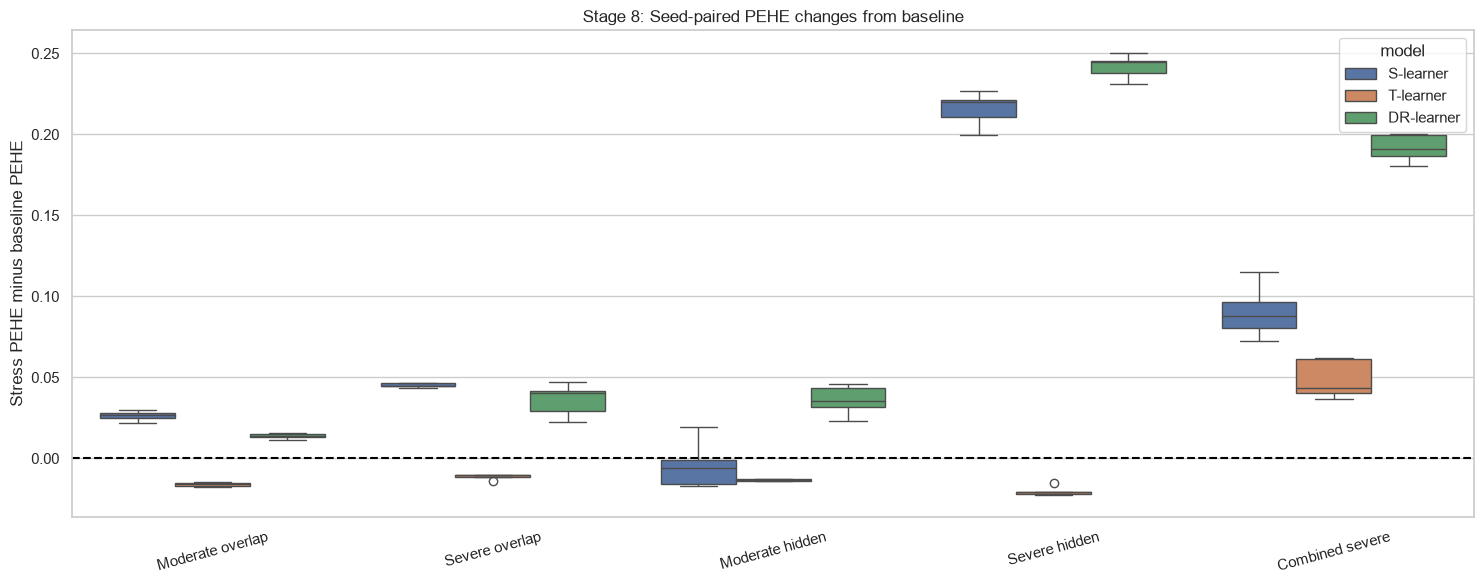

Stage 8 checks passed: 5 seeds, 6 scenarios, 180 policy results, six figures.


In [8]:
deltas = pd.read_csv(TABLES / "stage8_effect_deltas.csv")
fig, axis = plt.subplots(figsize=(15, 6))
sns.boxplot(data=deltas[deltas.scenario != "Baseline"], x="scenario", y="baseline_delta", hue="model",
            order=SCENARIOS[1:], hue_order=MODELS, ax=axis)
axis.axhline(0, color="black", linestyle="--")
axis.set(title="Stage 8: Seed-paired PEHE changes from baseline", xlabel="", ylabel="Stress PEHE minus baseline PEHE")
axis.tick_params(axis="x", labelrotation=15)
save(fig, "stage8_paired_effect_changes.png")
n, s = len(SEEDS), len(SCENARIOS)
assert len(effects) == n*s*3 and len(policies) == n*s*6 and len(diagnostics) == n*s
for frame, suffix in [(effects, ["model"]), (policies, ["policy"]), (diagnostics, [])]:
    assert set(frame.seed) == set(SEEDS) and set(frame.scenario) == set(SCENARIOS)
    assert not frame.duplicated(["seed", "scenario", *suffix]).any()
assert np.isfinite(effects.select_dtypes(include="number")).all().all()
assert np.isfinite(policies[["incremental_profit", "regret_vs_oracle"]]).all().all()
assert policies.capacity_feasible.all() and (policies.regret_vs_oracle >= -1e-7).all()
assert (policies[policies.policy == "Treat nobody"].incremental_profit == 0).all()
no_hidden = diagnostics[diagnostics.hidden_strength == 0]
hidden = diagnostics[diagnostics.hidden_strength > 0]
assert np.allclose(no_hidden.analytic_identification_gap, 0, atol=1e-12)
assert (hidden.analytic_identification_gap > 0).all()
weak = diagnostics.pivot(index="seed", columns="scenario", values="true_weak_overlap_fraction")
assert (weak["Severe overlap"] > weak["Baseline"]).all()
pd.testing.assert_frame_equal(deltas, paired_baseline_deltas(effects, "pehe", ["model"]), check_dtype=False, atol=1e-7)
for name, rows in manifest["rows"].items():
    assert len(pd.read_csv(TABLES / name)) == rows
expected = ["stage8_propensity_overlap.png", "stage8_effect_errors.png", "stage8_identification_failure.png",
            "stage8_policy_stress.png", "stage8_clipping_and_trimming.png", "stage8_paired_effect_changes.png"]
assert all((FIGURES / name).is_file() and (FIGURES / name).stat().st_size > 0 for name in expected)
print(f"Stage 8 checks passed: {n} seeds, {s} scenarios, {len(policies)} policy results, six figures.")